# Modelo SVM para ObesiApp con NHANES

**Proyecto:** ObesiApp — Predicción de riesgo de obesidad infantil  
**Algoritmo:** Máquinas de Vectores de Soporte (SVM)  
**Dataset:** NHANES 2017–March 2020 Pre-Pandemic  
**Población:** niños y niñas de 6 a 12 años  


## 1. Introducción

La obesidad infantil es una problemática de salud pública que puede afectar el bienestar físico, emocional y social de los niños. Detectar oportunamente factores de riesgo permite promover hábitos saludables y apoyar la toma de decisiones de tutores, docentes o profesionales de la salud.

En el proyecto **ObesiApp**, el objetivo es apoyar la prevención de obesidad infantil mediante el análisis de variables como edad, sexo, peso, estatura e índice de masa corporal (IMC).

Para este desempeño se implementa el algoritmo **Máquinas de Vectores de Soporte (SVM)** con el propósito de clasificar el nivel de riesgo de obesidad infantil en tres categorías:

- **bajo**
- **medio**
- **alto**

El modelo tiene fines académicos y preventivos. No sustituye una valoración médica.


## 2. Explicación del algoritmo SVM

Las **Máquinas de Vectores de Soporte** son algoritmos de **aprendizaje supervisado** utilizados para clasificación y regresión.

En clasificación, SVM busca encontrar una frontera de decisión llamada **hiperplano**, que separe las clases de la mejor forma posible. Para lograrlo, el algoritmo maximiza el margen entre las clases. Los puntos más cercanos a la frontera se llaman **vectores de soporte**, porque son los que influyen directamente en la posición del hiperplano.

### Lógica del algoritmo

1. Recibe datos de entrenamiento con etiquetas.
2. Busca una frontera para separar las clases.
3. Maximiza el margen entre las clases.
4. Usa los vectores de soporte para definir la frontera.
5. Si las clases no son linealmente separables, utiliza funciones **kernel**.

### Kernel usado

En este notebook se utiliza el **kernel RBF**, porque permite trabajar con relaciones no lineales entre variables como IMC, peso, estatura y edad.

### Ventajas

- Funciona bien en problemas de clasificación.
- Puede manejar relaciones no lineales con kernels.
- Tiene buena capacidad de generalización.

### Limitaciones

- Requiere escalamiento de datos.
- Puede ser sensible a parámetros como `C` y `gamma`.
- No entrega importancia de variables de forma directa como Random Forest.

### Aplicaciones reales

- Diagnóstico asistido.
- Clasificación médica.
- Detección de patrones.
- Clasificación de imágenes.
- Detección de spam.


## 3. Carga de librerías

Se importan las librerías necesarias para descargar datos, limpiarlos, entrenar el modelo, evaluarlo, graficar resultados y guardar el modelo.


In [1]:
# Impoetacion de librerias
# !pip install pandas numpy scikit-learn joblib matplotlib pyreadstat

from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
MODEL_DIR = Path("models")
FIG_DIR = Path("figures")

for directory in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print("Carpetas listas.")


Carpetas listas.


## 4. Obtención de los datos

Se utiliza el dataset público **NHANES**. En este notebook se descargan dos archivos principales:

- **P_DEMO:** datos demográficos, como edad y sexo.
- **P_BMX:** medidas corporales, como peso, estatura, IMC y categoría de IMC infantil.

Estos datos se descargan y se guardan como archivos CSV locales dentro de la carpeta `data/raw/`.


In [2]:
# Código correspondiente a esta etapa del proceso de Machine Learning.
# Lee las instrucciones de la celda Markdown anterior para comprender su propósito.

urls = {
    "demo": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.xpt",
    "bmx": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.xpt",
}

for name, url in urls.items():
    csv_path = RAW_DIR / f"{name}.csv"
    if csv_path.exists():
        print(f"{name}.csv ya existe. No se descarga de nuevo.")
    else:
        print(f"Descargando {name}...")
        df_temp = pd.read_sas(url, format="xport")
        df_temp.to_csv(csv_path, index=False)
        print(f"{name}: {df_temp.shape}")

print("Descarga terminada.")


Descargando demo...
demo: (15560, 29)
Descargando bmx...
bmx: (14300, 22)
Descarga terminada.


## 5. Carga y revisión inicial de datos

Se cargan los archivos descargados y se revisan sus primeras filas para comprobar que la información esté disponible.


In [3]:
# Código correspondiente a esta etapa del proceso de Machine Learning.

demo = pd.read_csv(RAW_DIR / "demo.csv")
bmx = pd.read_csv(RAW_DIR / "bmx.csv")

print("demo:", demo.shape)
print("bmx:", bmx.shape)

display(demo.head())
display(bmx.head())


demo: (15560, 29)
bmx: (14300, 22)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINTPRP,WTMECPRP,SDMVPSU,SDMVSTRA,INDFMPIR
0,109263.0,66.0,2.0,1.0,2.0,NaN,5.0,6.0,2.0,1.0,...,2.0,NaN,NaN,NaN,NaN,7891.762435,8.951816e+03,3.0,156.0,4.66
1,109264.0,66.0,2.0,2.0,13.0,NaN,1.0,1.0,2.0,1.0,...,2.0,1.0,2.0,2.0,1.0,11689.747264,1.227116e+04,1.0,155.0,0.83
2,109265.0,66.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,1.0,...,2.0,NaN,NaN,NaN,NaN,16273.825939,1.665876e+04,1.0,157.0,3.06
3,109266.0,66.0,2.0,2.0,29.0,NaN,5.0,6.0,2.0,2.0,...,2.0,1.0,2.0,2.0,1.0,7825.646112,8.154968e+03,2.0,168.0,5.00
4,109267.0,66.0,1.0,2.0,21.0,NaN,2.0,2.0,NaN,2.0,...,2.0,NaN,NaN,NaN,NaN,26379.991724,5.397605e-79,1.0,156.0,5.00


,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,109263.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264.0,1.0,42.2,NaN,NaN,NaN,NaN,NaN,154.7,NaN,...,36.3,NaN,33.8,NaN,22.7,NaN,63.8,NaN,85.0,NaN
2,109265.0,1.0,12.0,NaN,91.6,NaN,NaN,NaN,89.3,NaN,...,NaN,NaN,18.6,NaN,14.8,NaN,41.2,NaN,NaN,NaN
3,109266.0,1.0,97.1,NaN,NaN,NaN,NaN,NaN,160.2,NaN,...,40.8,NaN,34.7,NaN,35.8,NaN,117.9,NaN,126.1,NaN
4,109269.0,3.0,13.6,NaN,90.9,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN


## 6. Limpieza y preprocesamiento

En esta sección se unen los datos demográficos con las medidas corporales mediante el identificador `SEQN`.

Después se realiza lo siguiente:

- Selección de columnas necesarias.
- Renombrado de variables.
- Filtrado de población infantil de 6 a 12 años.
- Eliminación de valores nulos.
- Recodificación de sexo.
- Creación de la variable objetivo `risk_level`.

La variable objetivo se crea a partir de `BMDBMIC`, que representa la categoría de IMC infantil:

- 1: Bajo peso → `bajo`
- 2: Peso normal → `bajo`
- 3: Sobrepeso → `medio`
- 4: Obesidad → `alto`


In [4]:
demo_cols = ["SEQN", "RIAGENDR", "RIDAGEYR"]
bmx_cols = ["SEQN", "BMXWT", "BMXHT", "BMXBMI", "BMDBMIC"]

data = demo[demo_cols].merge(bmx[bmx_cols], on="SEQN", how="inner")

data = data.rename(columns={
    "SEQN": "participant_id",
    "RIAGENDR": "gender_code",
    "RIDAGEYR": "age",
    "BMXWT": "weight_kg",
    "BMXHT": "height_cm",
    "BMXBMI": "bmi",
    "BMDBMIC": "bmi_child_category"
})

# Filtrar población infantil de ObesiApp
data = data[(data["age"] >= 6) & (data["age"] <= 12)].copy()

# Eliminar registros incompletos
data = data.dropna(subset=[
    "gender_code", "age", "weight_kg", "height_cm", "bmi", "bmi_child_category"
])

# Recodificar sexo
data["gender"] = data["gender_code"].map({1: "male", 2: "female"})

# Crear variable objetivo
def map_risk(category):
    category = int(category)
    if category in [1, 2]:
        return "bajo"
    if category == 3:
        return "medio"
    if category == 4:
        return "alto"
    return np.nan

data["risk_level"] = data["bmi_child_category"].apply(map_risk)
data = data.dropna(subset=["risk_level"])

final_cols = [
    "participant_id", "age", "gender", "gender_code",
    "weight_kg", "height_cm", "bmi", "bmi_child_category", "risk_level"
]

clean = data[final_cols].copy()

print("Dataset limpio:", clean.shape)
display(clean.head())


Dataset limpio: (2003, 9)


,participant_id,age,gender,gender_code,weight_kg,height_cm,bmi,bmi_child_category,risk_level
5,109270.0,11.0,female,2.0,75.3,156.0,30.9,4.0,alto
10,109275.0,6.0,male,1.0,20.9,120.4,14.4,2.0,bajo
12,109277.0,12.0,female,2.0,48.7,162.0,18.6,2.0,bajo
13,109278.0,6.0,female,2.0,20.5,112.0,16.3,2.0,bajo
21,109287.0,11.0,female,2.0,40.4,145.1,19.2,2.0,bajo


## 7. Guardado del dataset limpio

Se guarda el dataset procesado para dejar evidencia de la etapa de limpieza.


In [5]:
clean_path = PROCESSED_DIR / "obesiapp_nhanes_clean.csv"
clean.to_csv(clean_path, index=False)
print("Dataset limpio guardado en:", clean_path.resolve())


Dataset limpio guardado en: C:\Users\yonat\github\Extraccion_de_conocimiento\Notebooks\data\processed\obesiapp_nhanes_clean.csv


## 8. Exploración inicial del dataset

Se revisan columnas, tipos de datos, valores nulos, duplicados y distribución de clases.


In [6]:
df = clean.copy()

print("Columnas disponibles:")
print(df.columns.tolist())

print("Información general:")
display(df.info())

print("Valores nulos por columna:")
display(df.isnull().sum())

print("Registros duplicados:", df.duplicated().sum())


Columnas disponibles:
['participant_id', 'age', 'gender', 'gender_code', 'weight_kg', 'height_cm', 'bmi', 'bmi_child_category', 'risk_level']
Información general:
<class 'pandas.core.frame.DataFrame'>
Index: 2003 entries, 5 to 14297
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   participant_id      2003 non-null   float64
 1   age                 2003 non-null   float64
 2   gender              2003 non-null   object 
 3   gender_code         2003 non-null   float64
 4   weight_kg           2003 non-null   float64
 5   height_cm           2003 non-null   float64
 6   bmi                 2003 non-null   float64
 7   bmi_child_category  2003 non-null   float64
 8   risk_level          2003 non-null   object 
dtypes: float64(7), object(2)
memory usage: 156.5+ KB


None

Valores nulos por columna:


participant_id        0
age                   0
gender                0
gender_code           0
weight_kg             0
height_cm             0
bmi                   0
bmi_child_category    0
risk_level            0
dtype: int64

Registros duplicados: 0


Distribución de clases:


risk_level
bajo     1232
alto      455
medio     316
Name: count, dtype: int64

Porcentaje por clase:


risk_level
bajo     61.51
alto     22.72
medio    15.78
Name: proportion, dtype: float64

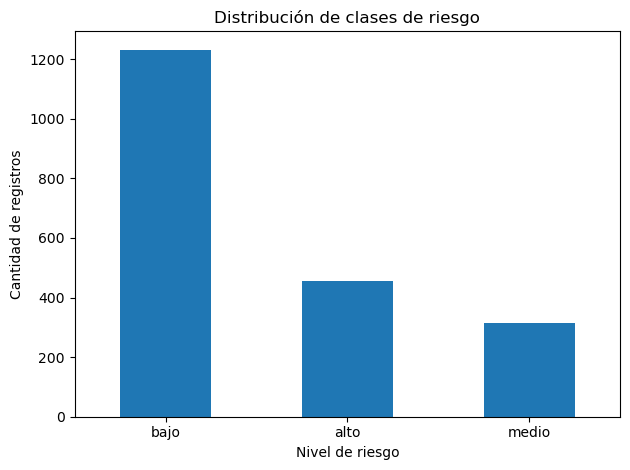

In [7]:
target = "risk_level"

print("Distribución de clases:")
display(df[target].value_counts())

print("Porcentaje por clase:")
display((df[target].value_counts(normalize=True) * 100).round(2))

df[target].value_counts().plot(kind="bar")
plt.title("Distribución de clases de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "distribucion_clases.png", dpi=150)
plt.show()


## 9. Importancia de las variables para el problema

### Variables predictoras

- `age`: edad del niño.
- `gender`: sexo.
- `weight_kg`: peso en kilogramos.
- `height_cm`: estatura en centímetros.
- `bmi`: índice de masa corporal.

### Variable objetivo

- `risk_level`: nivel de riesgo de obesidad infantil.

Estas variables fueron seleccionadas porque tienen relación directa con la clasificación de riesgo basada en IMC infantil.


In [8]:
features = ["age", "gender", "weight_kg", "height_cm", "bmi"]
target = "risk_level"

model_df = df[features + [target]].dropna().copy()

X = model_df[features]
y = model_df[target]

print("Dimensiones finales para modelado:", model_df.shape)
display(model_df.head())


Dimensiones finales para modelado: (2003, 6)


,age,gender,weight_kg,height_cm,bmi,risk_level
5,11.0,female,75.3,156.0,30.9,alto
10,6.0,male,20.9,120.4,14.4,bajo
12,12.0,female,48.7,162.0,18.6,bajo
13,6.0,female,20.5,112.0,16.3,bajo
21,11.0,female,40.4,145.1,19.2,bajo


## 10. Separación de datos: entrenamiento y prueba

El dataset se divide en:

- **80% entrenamiento**
- **20% prueba**

Se utiliza `random_state=42` para obtener resultados reproducibles.

También se utiliza `stratify=y` para mantener la proporción de clases en entrenamiento y prueba.

Esto evita que alguna clase quede mal representada en la evaluación.


In [9]:
# División del conjunto de datos en entrenamiento y prueba.
# Se utiliza stratify para conservar la proporción de clases.
# random_state=42 garantiza resultados reproducibles.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

print("Distribución en entrenamiento:")
display(y_train.value_counts(normalize=True).round(3))

print("Distribución en prueba:")
display(y_test.value_counts(normalize=True).round(3))


Tamaño de entrenamiento: (1602, 5)
Tamaño de prueba: (401, 5)
Distribución en entrenamiento:


risk_level
bajo     0.615
alto     0.227
medio    0.158
Name: proportion, dtype: float64

Distribución en prueba:


risk_level
bajo     0.616
alto     0.227
medio    0.157
Name: proportion, dtype: float64

## 11. Implementación del modelo SVM

Se construye un `Pipeline` para que el preprocesamiento y el entrenamiento se realicen de forma ordenada.

El pipeline incluye:

1. Codificación de la variable categórica `gender` con `OneHotEncoder`.
2. Escalamiento de variables numéricas con `StandardScaler`.
3. Entrenamiento del modelo `SVC` con kernel RBF.

El escalamiento es indispensable porque SVM trabaja con distancias. Si una variable tiene una escala muy grande, puede influir más de lo debido.


In [10]:
# Escalado de variables.
# SVM requiere que todas las variables estén en la misma escala.
# fit() solo aprende con entrenamiento y transform() aplica el mismo cambio al conjunto de prueba.

numeric_features = ["age", "weight_kg", "height_cm", "bmi"]
categorical_features = ["gender"]

# Compatibilidad entre versiones de scikit-learn
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", svm_model)
])

clf.fit(X_train, y_train)

print("Modelo SVM entrenado correctamente.")


Modelo SVM entrenado correctamente.


## 12. Evaluación del modelo

Como el problema es de clasificación, se utilizan las siguientes métricas:

- **Accuracy:** porcentaje total de predicciones correctas.
- **Precision:** de los casos que el modelo predijo como una clase, cuántos realmente eran de esa clase.
- **Recall:** de los casos reales de una clase, cuántos logró identificar el modelo.
- **F1-score:** equilibrio entre precision y recall.
- **Matriz de confusión:** muestra aciertos y errores por clase.


Accuracy: 0.9377
Reporte de clasificación:
              precision    recall  f1-score   support

        alto       1.00      0.96      0.98        91
        bajo       1.00      0.91      0.96       247
       medio       0.72      1.00      0.83        63

    accuracy                           0.94       401
   macro avg       0.91      0.96      0.92       401
weighted avg       0.96      0.94      0.94       401



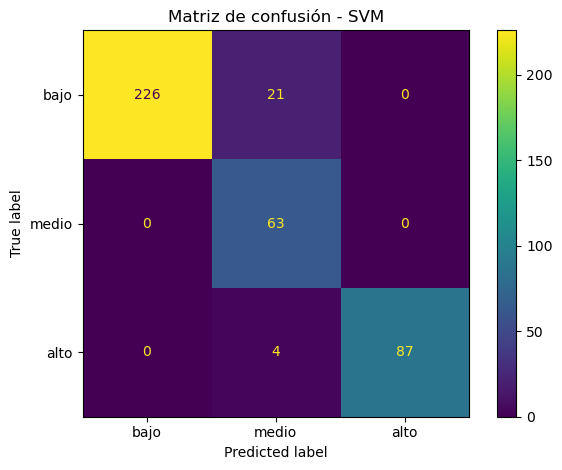

In [11]:
# Predicción sobre datos de prueba o nuevos registros.
# El modelo utiliza lo aprendido durante el entrenamiento.

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

labels = ["bajo", "medio", "alto"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Matriz de confusión - SVM")
plt.tight_layout()
plt.savefig(FIG_DIR / "matriz_confusion_svm.png", dpi=150)
plt.show()


## 13. Importancia de variables

SVM no genera importancia de variables de forma directa como Random Forest.

Por esa razón se utiliza **Permutation Importance**, una técnica que mide cuánto disminuye el desempeño del modelo cuando una variable se altera aleatoriamente.

Si el desempeño baja mucho, significa que esa variable era importante para el modelo.


,variable,importance_mean,importance_std
4,bmi,0.444140,0.026985
2,weight_kg,0.213716,0.014798
0,age,0.162843,0.019638
3,height_cm,0.072319,0.013196
1,gender,0.007232,0.004523


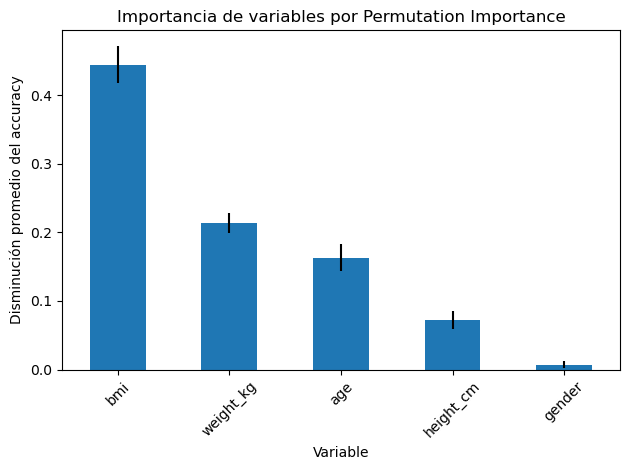

In [12]:
result = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "variable": features,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False)

display(importance_df)

importance_df.plot(
    x="variable",
    y="importance_mean",
    kind="bar",
    legend=False,
    yerr="importance_std"
)
plt.title("Importancia de variables por Permutation Importance")
plt.xlabel("Variable")
plt.ylabel("Disminución promedio del accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "importancia_variables_svm.png", dpi=150)
plt.show()


## 14. Implementación con datos nuevos

Se prueba el modelo con datos nuevos de un niño.

El formato de entrada debe respetar las mismas variables utilizadas en el entrenamiento:

- `age`
- `gender`
- `weight_kg`
- `height_cm`
- `bmi`

El pipeline aplica automáticamente la codificación y el escalamiento.


In [13]:
# Predicción sobre datos de prueba o nuevos registros.
# El modelo utiliza lo aprendido durante el entrenamiento.

nuevo_nino = pd.DataFrame([
    {
        "age": 10,
        "gender": "female",
        "weight_kg": 48,
        "height_cm": 138,
        "bmi": 48 / (1.38 ** 2)
    }
])

display(nuevo_nino)

prediccion = clf.predict(nuevo_nino)[0]
probabilidades = clf.predict_proba(nuevo_nino)[0]
clases = clf.classes_

print("Predicción del modelo:", prediccion)
print("Probabilidades por clase:")
for clase, prob in zip(clases, probabilidades):
    print(f"{clase}: {prob:.4f}")


,age,gender,weight_kg,height_cm,bmi
0,10,female,48,138,25.204789


Predicción del modelo: alto
Probabilidades por clase:
alto: 0.9990
bajo: 0.0005
medio: 0.0005


### Interpretación de la predicción

El modelo recibe los datos del nuevo niño, aplica el mismo preprocesamiento usado durante el entrenamiento y genera una clasificación de riesgo.

En el contexto de ObesiApp, este resultado podría utilizarse para mostrar recomendaciones generales de hábitos saludables o sugerir seguimiento por parte del tutor.

La predicción debe interpretarse como una estimación preventiva, no como diagnóstico médico.


## 15. Guardado del modelo

Se guarda el pipeline completo, incluyendo preprocesamiento y modelo SVM. Esto permite reutilizarlo posteriormente sin aplicar manualmente el escalamiento o la codificación.


In [14]:
# Guardado del modelo entrenado y del StandardScaler.
# Estos archivos permiten reutilizar el modelo sin volver a entrenarlo.

model_path = MODEL_DIR / "obesiapp_svm_model.pkl"
joblib.dump(clf, model_path)
print("Modelo SVM guardado en:", model_path.resolve())


Modelo SVM guardado en: C:\Users\yonat\github\Extraccion_de_conocimiento\Notebooks\models\obesiapp_svm_model.pkl


## 16. Conclusiones

El algoritmo **SVM** permitió construir un modelo de clasificación para estimar el riesgo de obesidad infantil a partir de variables físicas y demográficas. El uso del kernel RBF fue adecuado porque permite identificar relaciones no lineales entre variables como IMC, peso, estatura y edad.

El escalamiento fue un paso indispensable, ya que SVM trabaja con distancias y puede verse afectado cuando las variables tienen diferentes magnitudes. Además, el uso de un pipeline permitió evitar errores de preprocesamiento y prevenir fuga de información, ya que el ajuste se realizó únicamente con los datos de entrenamiento.

Las métricas de evaluación como accuracy, precision, recall y F1-score permitieron analizar el desempeño del modelo. La matriz de confusión ayudó a identificar en qué clases el modelo tuvo más aciertos o errores.

Una limitación importante es que el modelo utiliza pocas variables. Como mejora futura se podrían integrar datos de actividad física, alimentación, sueño y tiempo frente a pantalla, ya que son factores importantes dentro del contexto de ObesiApp.

Este trabajo permitió comprender que un mismo dataset puede utilizarse con diferentes algoritmos. Aunque ObesiApp ya cuenta con un modelo Random Forest, este notebook demuestra la implementación y análisis de SVM como alternativa supervisada para clasificación.
